# House Prices - Kaggle Competition
## Ensemble Methods: Random Forest & Gradient Boosting

Predicción de precios de casas usando métodos de ensamble.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

## 2. Carga de datos

In [2]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Análisis Exploratorio (EDA)

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


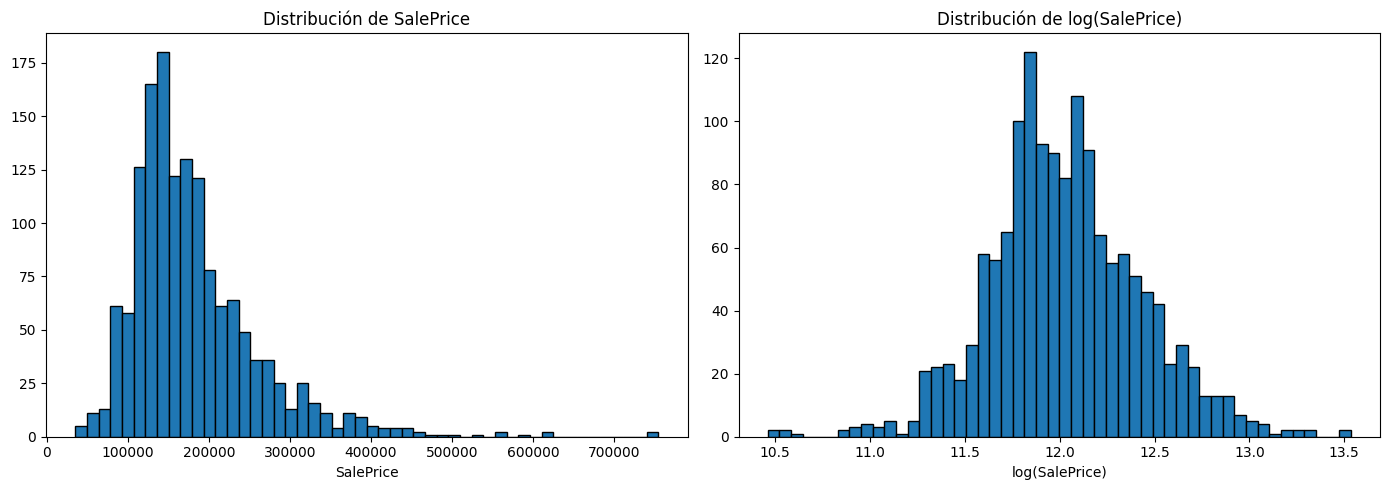

In [5]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['SalePrice'], bins=50, edgecolor='black')
axes[0].set_title('Distribución de SalePrice')
axes[0].set_xlabel('SalePrice')

axes[1].hist(np.log1p(train['SalePrice']), bins=50, edgecolor='black')
axes[1].set_title('Distribución de log(SalePrice)')
axes[1].set_xlabel('log(SalePrice)')

plt.tight_layout()
plt.show()

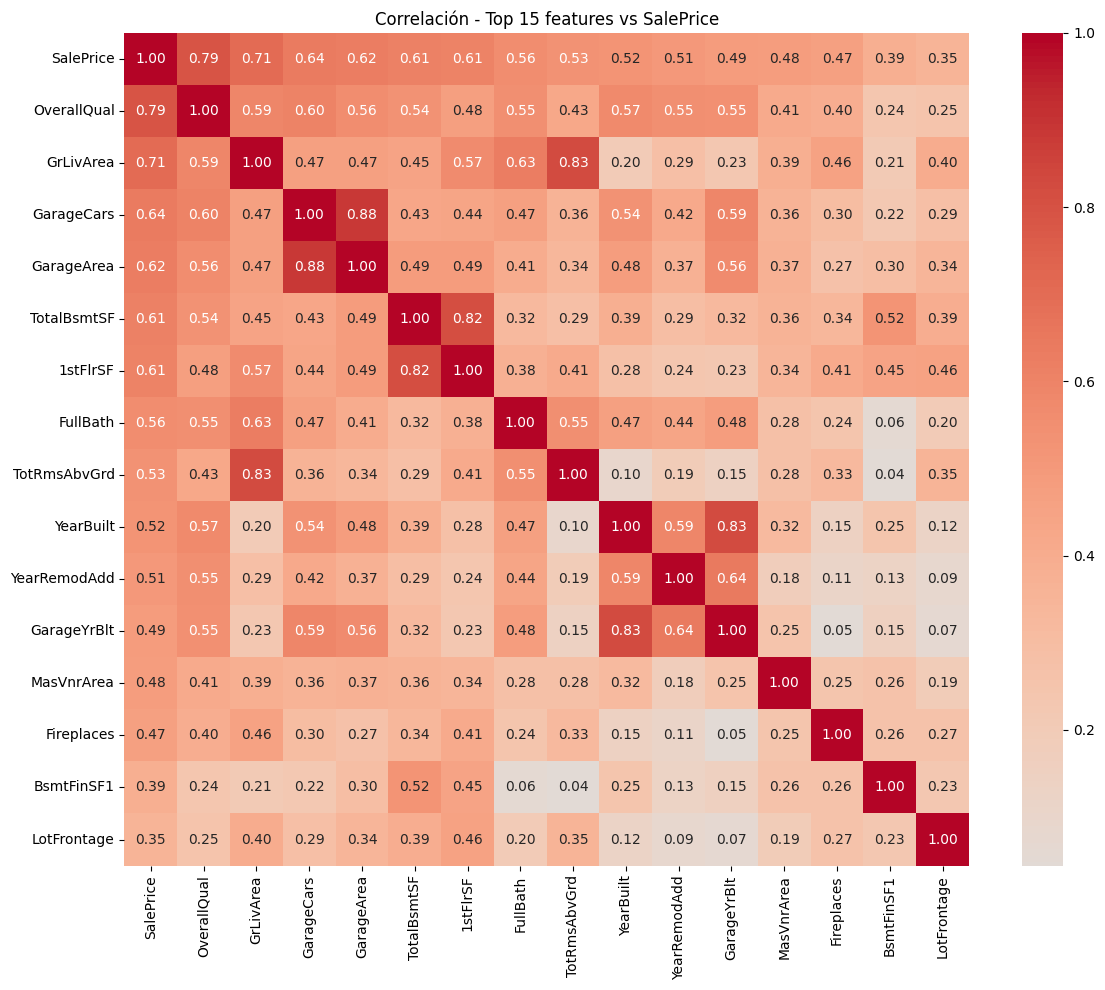

Top 15 features correlacionadas con SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64


In [6]:
# Correlación con SalePrice (top 15 features)
numeric_cols = train.select_dtypes(include=[np.number]).columns
correlation = train[numeric_cols].corr()['SalePrice'].abs().sort_values(ascending=False)
top_features = correlation.head(16).index  # 15 + SalePrice

plt.figure(figsize=(12, 10))
sns.heatmap(train[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación - Top 15 features vs SalePrice')
plt.tight_layout()
plt.show()

print("Top 15 features correlacionadas con SalePrice:")
print(correlation.head(16))

## 4. Análisis de valores nulos

In [7]:
# Valores nulos en train y test
null_train = train.isnull().sum()
null_test = test.isnull().sum()

null_df = pd.DataFrame({
    'Train_nulls': null_train[null_train > 0],
    'Train_%': (null_train[null_train > 0] / len(train) * 100).round(2),
    'Test_nulls': null_test.reindex(null_train[null_train > 0].index),
    'Test_%': (null_test.reindex(null_train[null_train > 0].index) / len(test) * 100).round(2)
}).sort_values('Train_%', ascending=False)

print(f"Columnas con nulos en train: {null_df.shape[0]}")
null_df

Columnas con nulos en train: 19


,Train_nulls,Train_%,Test_nulls,Test_%
PoolQC,1453,99.52,1456,99.79
MiscFeature,1406,96.30,1408,96.50
Alley,1369,93.77,1352,92.67
Fence,1179,80.75,1169,80.12
MasVnrType,872,59.73,894,61.27
FireplaceQu,690,47.26,730,50.03
LotFrontage,259,17.74,227,15.56
GarageType,81,5.55,76,5.21
GarageYrBlt,81,5.55,78,5.35
GarageFinish,81,5.55,78,5.35


## 5. Preprocesamiento

Combinamos train y test para aplicar las mismas transformaciones.

In [8]:
# Guardar IDs y target
train_ids = train['Id']
test_ids = test['Id']
y = np.log1p(train['SalePrice'])  # Transformación log para normalizar

# Eliminar Id y SalePrice antes de combinar
train_features = train.drop(['Id', 'SalePrice'], axis=1)
test_features = test.drop(['Id'], axis=1)

# Combinar para preprocesar juntos
ntrain = train_features.shape[0]
all_data = pd.concat([train_features, test_features], axis=0, ignore_index=True)
print(f"All data shape: {all_data.shape}")

All data shape: (2919, 79)


In [9]:
# Eliminar columnas con demasiados nulos (>80%)
high_null_cols = [col for col in all_data.columns if all_data[col].isnull().sum() / len(all_data) > 0.80]
print(f"Columnas eliminadas por >80% nulos: {high_null_cols}")
all_data = all_data.drop(high_null_cols, axis=1)

# Imputar valores nulos
# Categóricas: rellenar con 'None' (muchos NA significan ausencia de la feature)
cat_cols = all_data.select_dtypes(include=['object']).columns
for col in cat_cols:
    all_data[col] = all_data[col].fillna('None')

# Numéricas: rellenar con la mediana
num_cols = all_data.select_dtypes(include=[np.number]).columns
for col in num_cols:
    all_data[col] = all_data[col].fillna(all_data[col].median())

print(f"Nulos restantes: {all_data.isnull().sum().sum()}")
print(f"Shape después de limpieza: {all_data.shape}")

Columnas eliminadas por >80% nulos: ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
Nulos restantes: 0
Shape después de limpieza: (2919, 75)


In [10]:
# Encoding de variables categóricas con LabelEncoder
label_encoders = {}
cat_cols = all_data.select_dtypes(include=['object']).columns

for col in cat_cols:
    le = LabelEncoder()
    all_data[col] = le.fit_transform(all_data[col].astype(str))
    label_encoders[col] = le

print(f"Variables categóricas codificadas: {len(cat_cols)}")
print(f"Shape final: {all_data.shape}")
all_data.head()

Variables categóricas codificadas: 39
Shape final: (2919, 75)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,4,65.0,8450,1,3,3,0,4,0,5,2,2,0,5,7,5,2003,2003,1,1,13,14,1,196.0,2,4,2,2,4,3,2,706.0,6,0.0,150.0,856.0,1,0,1,5,856,854,0,1710,1.0,0.0,2,1,3,1,2,8,7,0,3,1,2003.0,2,2.0,548.0,5,5,2,0,61,0,0,0,0,0,2,2008,9,4
1,20,4,80.0,9600,1,3,3,0,2,0,24,1,2,0,2,6,8,1976,1976,1,1,8,8,2,0.0,3,4,1,2,4,1,0,978.0,6,0.0,284.0,1262.0,1,0,1,5,1262,0,0,1262,0.0,1.0,2,0,3,1,4,6,7,1,5,1,1976.0,2,2.0,460.0,5,5,2,298,0,0,0,0,0,0,5,2007,9,4
2,60,4,68.0,11250,1,0,3,0,4,0,5,2,2,0,5,7,5,2001,2002,1,1,13,14,1,162.0,2,4,2,2,4,2,2,486.0,6,0.0,434.0,920.0,1,0,1,5,920,866,0,1786,1.0,0.0,2,1,3,1,2,6,7,1,5,1,2001.0,2,2.0,608.0,5,5,2,0,42,0,0,0,0,0,9,2008,9,4
3,70,4,60.0,9550,1,0,3,0,0,0,6,2,2,0,5,7,5,1915,1970,1,1,14,16,2,0.0,3,4,0,4,1,3,0,216.0,6,0.0,540.0,756.0,1,2,1,5,961,756,0,1717,1.0,0.0,1,0,3,1,2,7,7,1,2,5,1998.0,3,3.0,642.0,5,5,2,0,35,272,0,0,0,0,2,2006,9,0
4,60,4,84.0,14260,1,0,3,0,2,0,15,2,2,0,5,8,5,2000,2000,1,1,13,14,1,350.0,2,4,2,2,4,0,2,655.0,6,0.0,490.0,1145.0,1,0,1,5,1145,1053,0,2198,1.0,0.0,2,1,4,1,2,9,7,1,5,1,2000.0,2,3.0,836.0,5,5,2,192,84,0,0,0,0,0,12,2008,9,4


## 6. Split train/test y validación

In [11]:
# Separar de nuevo en train y test
X = all_data[:ntrain]
X_test_final = all_data[ntrain:]

# Split para validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test_final (Kaggle): {X_test_final.shape}")

X_train: (1168, 75)
X_val: (292, 75)
X_test_final (Kaggle): (1459, 75)


## 7. Modelo 1: Random Forest

In [12]:
# Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predicciones
rf_train_pred = rf.predict(X_train)
rf_val_pred = rf.predict(X_val)

# Métricas (en escala log)
print("=== Random Forest ===")
print(f"Train RMSE (log): {np.sqrt(mean_squared_error(y_train, rf_train_pred)):.4f}")
print(f"Val RMSE (log):   {np.sqrt(mean_squared_error(y_val, rf_val_pred)):.4f}")
print(f"Val MAE (log):    {mean_absolute_error(y_val, rf_val_pred):.4f}")
print(f"Val R²:           {r2_score(y_val, rf_val_pred):.4f}")

# Cross-validation
rf_cv = cross_val_score(rf, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f"CV RMSE (log):    {-rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})")

=== Random Forest ===
Train RMSE (log): 0.0796
Val RMSE (log):   0.1578
Val MAE (log):    0.0999
Val R²:           0.8666


CV RMSE (log):    0.1438 (+/- 0.0098)


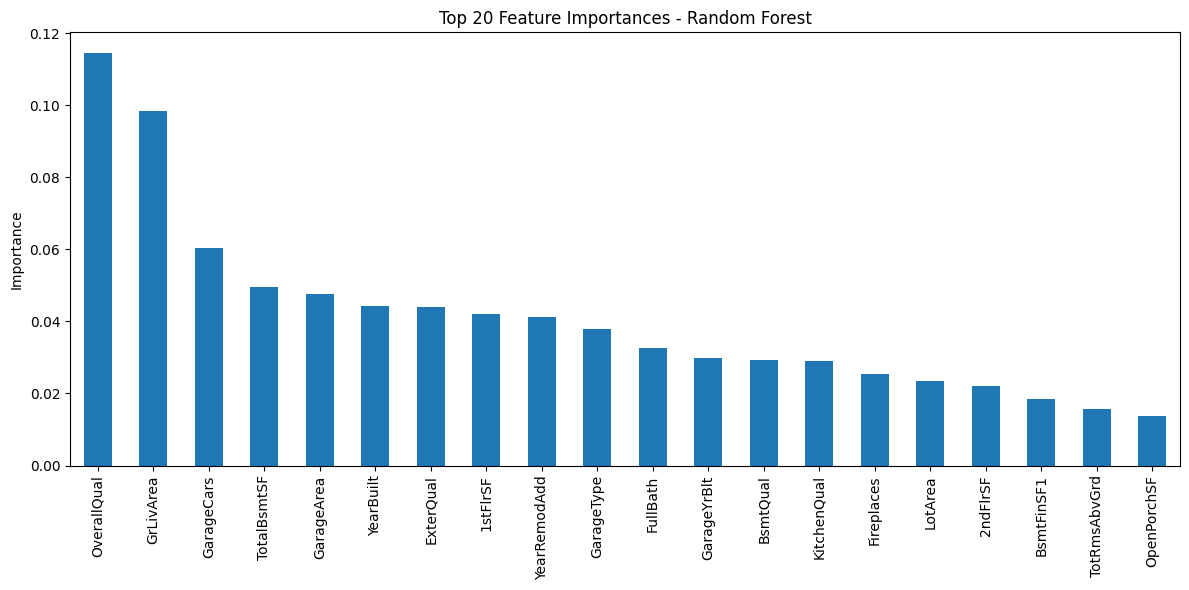

In [13]:
# Feature importance - Random Forest
rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
rf_importances.head(20).plot(kind='bar')
plt.title('Top 20 Feature Importances - Random Forest')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## 8. Modelo 2: Gradient Boosting

In [14]:
# Gradient Boosting
gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.8,
    max_features='sqrt',
    random_state=42
)

gb.fit(X_train, y_train)

# Predicciones
gb_train_pred = gb.predict(X_train)
gb_val_pred = gb.predict(X_val)

# Métricas
print("=== Gradient Boosting ===")
print(f"Train RMSE (log): {np.sqrt(mean_squared_error(y_train, gb_train_pred)):.4f}")
print(f"Val RMSE (log):   {np.sqrt(mean_squared_error(y_val, gb_val_pred)):.4f}")
print(f"Val MAE (log):    {mean_absolute_error(y_val, gb_val_pred):.4f}")
print(f"Val R²:           {r2_score(y_val, gb_val_pred):.4f}")

# Cross-validation
gb_cv = cross_val_score(gb, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f"CV RMSE (log):    {-gb_cv.mean():.4f} (+/- {gb_cv.std():.4f})")

=== Gradient Boosting ===
Train RMSE (log): 0.0435
Val RMSE (log):   0.1296
Val MAE (log):    0.0867
Val R²:           0.9100


CV RMSE (log):    0.1230 (+/- 0.0111)


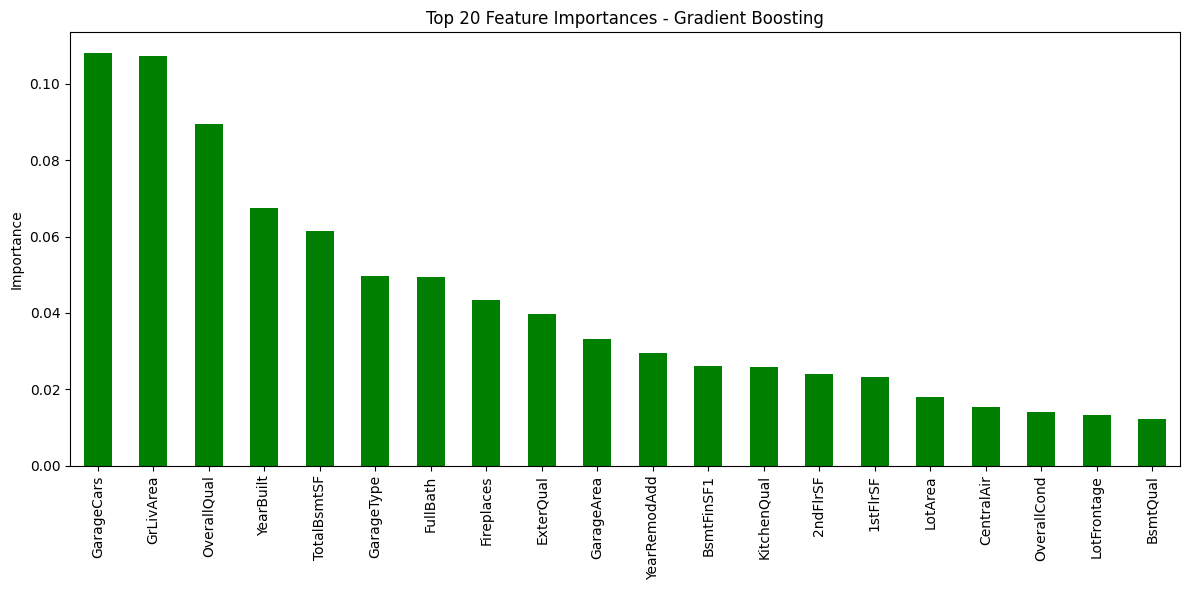

In [15]:
# Feature importance - Gradient Boosting
gb_importances = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
gb_importances.head(20).plot(kind='bar', color='green')
plt.title('Top 20 Feature Importances - Gradient Boosting')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## 9. Comparación de modelos

           Modelo  Val RMSE (log)   Val R²  CV RMSE (log)
    Random Forest        0.157802 0.866560       0.143776
Gradient Boosting        0.129569 0.910036       0.123010


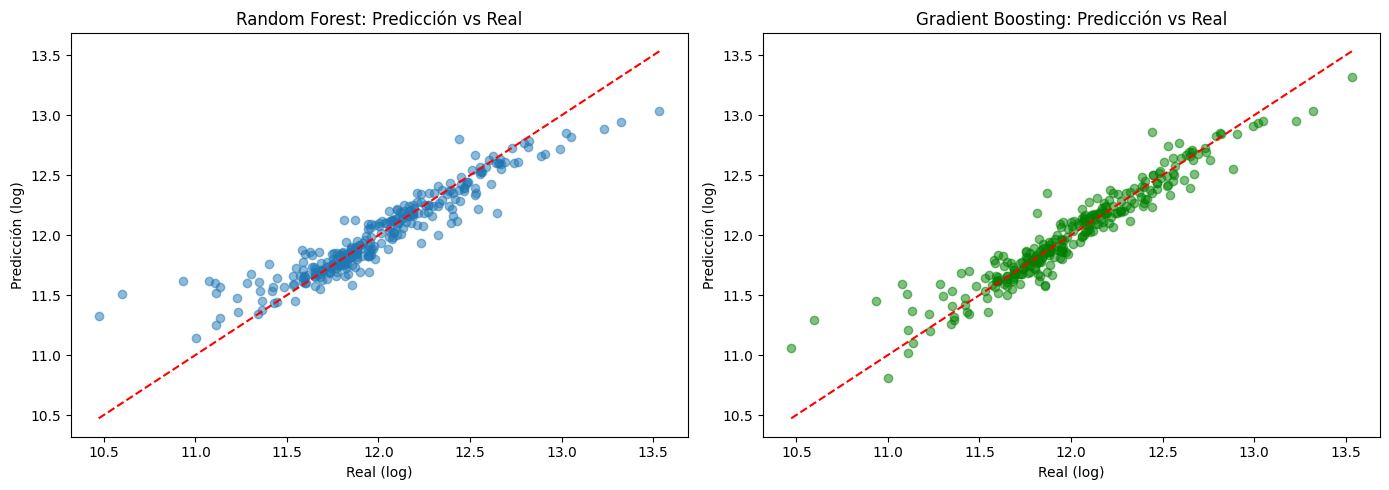

In [16]:
# Comparación de modelos
results = pd.DataFrame({
    'Modelo': ['Random Forest', 'Gradient Boosting'],
    'Val RMSE (log)': [
        np.sqrt(mean_squared_error(y_val, rf_val_pred)),
        np.sqrt(mean_squared_error(y_val, gb_val_pred))
    ],
    'Val R²': [
        r2_score(y_val, rf_val_pred),
        r2_score(y_val, gb_val_pred)
    ],
    'CV RMSE (log)': [
        -rf_cv.mean(),
        -gb_cv.mean()
    ]
})
print(results.to_string(index=False))

# Gráfico de comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicciones vs Real - Random Forest
axes[0].scatter(y_val, rf_val_pred, alpha=0.5)
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
axes[0].set_xlabel('Real (log)')
axes[0].set_ylabel('Predicción (log)')
axes[0].set_title('Random Forest: Predicción vs Real')

# Predicciones vs Real - Gradient Boosting
axes[1].scatter(y_val, gb_val_pred, alpha=0.5, color='green')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
axes[1].set_xlabel('Real (log)')
axes[1].set_ylabel('Predicción (log)')
axes[1].set_title('Gradient Boosting: Predicción vs Real')

plt.tight_layout()
plt.show()

## 10. Ensemble: Promedio de modelos y generación de submission

In [17]:
# Re-entrenar con TODOS los datos de train para la submission final
rf_final = RandomForestRegressor(
    n_estimators=300, max_depth=15, min_samples_split=5,
    min_samples_leaf=2, max_features='sqrt', random_state=42, n_jobs=-1
)
gb_final = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    min_samples_split=5, min_samples_leaf=3, subsample=0.8,
    max_features='sqrt', random_state=42
)

rf_final.fit(X, y)
gb_final.fit(X, y)

# Predicciones sobre test
rf_test_pred = rf_final.predict(X_test_final)
gb_test_pred = gb_final.predict(X_test_final)

# Ensemble: promedio ponderado (más peso a Gradient Boosting que suele ser mejor)
ensemble_pred = 0.4 * rf_test_pred + 0.6 * gb_test_pred

# Revertir transformación log
final_predictions = np.expm1(ensemble_pred)

print(f"Predicciones generadas: {len(final_predictions)}")
print(f"Precio medio predicho: ${final_predictions.mean():,.0f}")
print(f"Precio min: ${final_predictions.min():,.0f}")
print(f"Precio max: ${final_predictions.max():,.0f}")

Predicciones generadas: 1459
Precio medio predicho: $176,408
Precio min: $53,285
Precio max: $531,198


In [18]:
# Generar CSV de submission
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_predictions
})

submission.to_csv('submission.csv', index=False)
print("Archivo 'submission.csv' generado correctamente.")
submission.head(10)

Archivo 'submission.csv' generado correctamente.


,Id,SalePrice
0,1461,127729.454842
1,1462,154154.646491
2,1463,181997.522155
3,1464,190820.252159
4,1465,186650.647779
5,1466,179150.246256
6,1467,176008.520654
7,1468,169551.101184
8,1469,175489.577987
9,1470,128765.880294
